# IPL Match Winner Prediction
### Predicting 2nd-innings win probability using advanced ML with Bayesian Shrinkage

**Dataset**: [Ball-by-Ball IPL Data](https://www.kaggle.com/datasets/jamiewelsh2/ball-by-ball-ipl) (Kaggle)
**Model**: Logistic Regression — AUC **0.9009**, Accuracy **81.52%**

**Key features used:**
- Match situation: CRR, RRR, wickets in hand, resource remaining, match phase
- Player quality (Bayesian-shrunk): career SR, phase SR, bowler phase economy
- In-match form: bowler economy this match, recent runs, dot %, boundary %
- Context: partnership runs, next batter SR, remaining bowler avg economy, venue chase win %

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## 2. Load Dataset

In [2]:
# Download dataset from Kaggle (first run only)
import kagglehub
path = kagglehub.dataset_download("jamiewelsh2/ball-by-ball-ipl")
print("Dataset downloaded to:", path)

Dataset downloaded to: C:\Users\Om Eppalpalli\.cache\kagglehub\datasets\jamiewelsh2\ball-by-ball-ipl\versions\1


In [3]:
df = pd.read_csv("ball_by_ball_ipl.csv")
print(f"Shape: {df.shape}")
print(f"Matches: {df['Match ID'].nunique()}")
df.head()

Shape: (239693, 35)
Matches: 1005


,Unnamed: 0,Match ID,Date,Venue,Bat First,Bat Second,Innings,Over,Ball,Batter,Non Striker,Bowler,Batter Runs,Extra Runs,Runs From Ball,Ball Rebowled,Extra Type,Wicket,Method,Player Out,Innings Runs,Innings Wickets,Target Score,Runs to Get,Balls Remaining,Winner,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
0,0,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,1,RD Gaikwad,DP Conway,UT Yadav,4,0,4,0,[],0,NaN,NaN,4,0,236,NaN,119,Chennai Super Kings,0,4,0,1,0,NaN,NaN,4,1
1,1,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,2,RD Gaikwad,DP Conway,UT Yadav,0,0,0,0,[],0,NaN,NaN,4,0,236,NaN,118,Chennai Super Kings,0,4,0,2,0,NaN,NaN,0,1
2,2,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,3,RD Gaikwad,DP Conway,UT Yadav,0,0,0,0,[],0,NaN,NaN,4,0,236,NaN,117,Chennai Super Kings,0,4,0,3,0,NaN,NaN,0,1
3,3,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,4,RD Gaikwad,DP Conway,UT Yadav,0,0,0,0,[],0,NaN,NaN,4,0,236,NaN,116,Chennai Super Kings,0,4,0,4,0,NaN,NaN,0,1
4,4,1359507,2023-04-23,Eden Gardens,Chennai Super Kings,Kolkata Knight Riders,1,1,5,RD Gaikwad,DP Conway,UT Yadav,1,0,1,0,[],0,NaN,NaN,5,0,236,NaN,115,Chennai Super Kings,0,5,0,5,0,NaN,NaN,1,1


## 3. Exploratory Data Analysis

In [4]:
print("Columns:", df.columns.tolist())
df.describe()

Columns: ['Unnamed: 0', 'Match ID', 'Date', 'Venue', 'Bat First', 'Bat Second', 'Innings', 'Over', 'Ball', 'Batter', 'Non Striker', 'Bowler', 'Batter Runs', 'Extra Runs', 'Runs From Ball', 'Ball Rebowled', 'Extra Type', 'Wicket', 'Method', 'Player Out', 'Innings Runs', 'Innings Wickets', 'Target Score', 'Runs to Get', 'Balls Remaining', 'Winner', 'Chased Successfully', 'Total Batter Runs', 'Total Non Striker Runs', 'Batter Balls Faced', 'Non Striker Balls Faced', 'Player Out Runs', 'Player Out Balls Faced', 'Bowler Runs Conceded', 'Valid Ball']


,Unnamed: 0,Match ID,Innings,Over,Ball,Batter Runs,Extra Runs,Runs From Ball,Ball Rebowled,Wicket,Innings Runs,Innings Wickets,Target Score,Runs to Get,Balls Remaining,Chased Successfully,Total Batter Runs,Total Non Striker Runs,Batter Balls Faced,Non Striker Balls Faced,Player Out Runs,Player Out Balls Faced,Bowler Runs Conceded,Valid Ball
count,239693.000000,2.396930e+05,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,115766.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,239693.000000,11827.000000,11827.000000,239693.000000,239693.000000
mean,119846.000000,8.695839e+05,1.482976,10.199964,3.489188,1.252373,0.067198,1.319571,0.035596,0.049342,75.346426,2.439687,165.590226,93.054956,61.346623,0.533774,17.180493,16.518338,13.567071,13.343681,18.753276,15.388602,1.294769,0.964404
std,69193.553374,3.537819e+05,0.499711,5.678629,1.708591,1.626859,0.342398,1.614630,0.185280,0.216582,48.642545,2.092265,31.115082,50.361519,34.101282,0.498859,18.295757,17.799281,12.103000,12.028558,19.643315,12.867069,1.619098,0.185280
min,0.000000,3.359820e+05,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.000000,-33.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,59923.000000,5.483140e+05,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.000000,1.000000,147.000000,53.000000,32.000000,0.000000,3.000000,3.000000,4.000000,4.000000,4.000000,5.000000,0.000000,1.000000
50%,119846.000000,8.298170e+05,1.000000,10.000000,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,71.000000,2.000000,166.000000,92.000000,62.000000,1.000000,11.000000,11.000000,10.000000,10.000000,12.000000,12.000000,1.000000,1.000000
75%,179769.000000,1.216507e+06,2.000000,15.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,111.000000,4.000000,186.000000,131.000000,91.000000,1.000000,26.000000,25.000000,20.000000,20.000000,28.000000,22.000000,1.000000,1.000000
max,239692.000000,1.370353e+06,2.000000,20.000000,7.000000,6.000000,7.000000,7.000000,1.000000,1.000000,263.000000,10.000000,264.000000,264.000000,120.000000,1.000000,175.000000,175.000000,74.000000,73.000000,129.000000,71.000000,7.000000,1.000000


Chase win rate: 54.5%  (548 wins / 1005 matches)


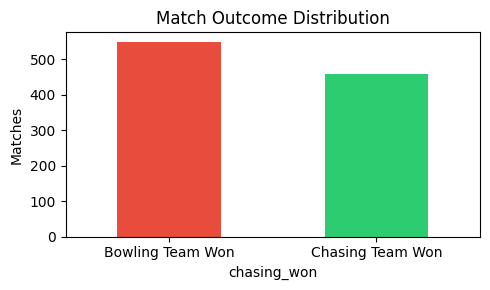

In [5]:
# Class balance: how often does the chasing team win?
matches = df[['Match ID','Bat Second','Winner']].drop_duplicates('Match ID')
matches['chasing_won'] = (matches['Bat Second'] == matches['Winner']).astype(int)
print(f"Chase win rate: {matches['chasing_won'].mean():.1%}  "
      f"({matches['chasing_won'].sum()} wins / {len(matches)} matches)")

matches['chasing_won'].value_counts().plot(kind='bar', color=['#e74c3c','#2ecc71'],
    title='Match Outcome Distribution', figsize=(5,3))
plt.xticks([0,1], ['Bowling Team Won','Chasing Team Won'], rotation=0)
plt.ylabel('Matches'); plt.tight_layout(); plt.show()

## 4. Data Preprocessing

Filter to in-progress 2nd-innings balls, standardise franchise names, and engineer base match-situation features.

In [6]:
# Standardise team names (franchise renames over IPL history)
rename_map = {
    'Delhi Daredevils':  'Delhi Capitals',
    'Deccan Chargers':   'Sunrisers Hyderabad',
    'Pune Warriors':     'Rising Pune Supergiants',
}

# Add phase column on full dataset — needed for per-phase player-stat aggregations
df['phase'] = pd.cut(
    (120 - df['Balls Remaining']) / 6,
    bins=[0, 6, 15, 20],
    labels=['Powerplay', 'Middle Overs', 'Death Overs'],
    include_lowest=True
)

for col in ['Bat Second', 'Bat First', 'Winner']:
    df[col] = df[col].replace(rename_map)

print("Unique teams:", sorted(df['Bat Second'].unique()))

Unique teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


In [7]:
# Filter: 2nd innings, match in-progress, valid deliveries only
df3 = df[
    (df['Innings'] == 2) &
    (df['Runs to Get'] > 0) &
    (df['Innings Wickets'] < 10) &
    (df['Valid Ball'] == 1) &
    (df['Balls Remaining'] > 0)
].copy()

for col in ['Bat Second', 'Bat First', 'Winner']:
    df3[col] = df3[col].replace(rename_map)

# ── Match-situation features ──────────────────────────────────────────────────
df3['overs_bowled']       = (120 - df3['Balls Remaining']) / 6
df3['crr']                = (df3['Innings Runs'] / df3['overs_bowled'].replace(0, 0.1)).round(2)
df3['rrr']                = (df3['Runs to Get'] / (df3['Balls Remaining'] / 6)).round(2).clip(upper=36)
df3['wickets_in_hand']    = 10 - df3['Innings Wickets']
df3['run_rate_pressure']  = (df3['rrr'] / df3['crr'].replace(0, 0.1)).round(2).clip(upper=20)
df3['resource_remaining'] = ((20 - df3['overs_bowled']) * (df3['wickets_in_hand'] / 10)).round(3)
df3['match_phase']        = pd.cut(df3['overs_bowled'], bins=[0, 6, 15, 20],
                                    labels=['Powerplay', 'Middle Overs', 'Death Overs'],
                                    include_lowest=True)
df3['chasing_team_wins']  = (df3['Bat Second'] == df3['Winner']).astype(int)

df3 = df3.sort_values(['Match ID', 'Over', 'Ball']).reset_index(drop=True)
print(f"Modelling dataset shape: {df3.shape}")
print(f"Chase win rate: {df3.groupby('Match ID')['chasing_team_wins'].first().mean():.1%}")

Modelling dataset shape: (110602, 44)
Chase win rate: 54.5%


## 5. Feature Engineering — Bayesian Shrinkage for Player Stats

**Problem**: A player who batted 10 balls at SR 200 doesn't deserve a 200 SR label — it's noise.

**Solution — Bayesian shrinkage**: pull each player's raw stat toward the population median, weighted by how much data we have:

```
shrunk_sr = (career_balls × raw_sr + C × median_sr) / (career_balls + C)
```

- `C = 100` balls for batters — with few balls the estimate collapses to median; with 500+ balls it tracks the raw SR closely
- `C = 60` balls for bowlers — bowlers generally have more consistent samples
- `C = 10` matches for venues — venues with 1-2 matches get pulled toward global average

This prevents outlier players from dominating the model signal.

## 6. Batter Career Statistics (Bayesian Shrinkage)

In [8]:
C_bat  = 100   # shrinkage prior balls for batters
C_bowl = 60    # shrinkage prior balls for bowlers

# ── Career batter stats ────────────────────────────────────────────────────────
batter_career = df.groupby('Batter').agg(
    career_runs  = ('Batter Runs', 'sum'),
    career_balls = ('Valid Ball',  'sum'),
).reset_index()
batter_career['career_sr'] = (batter_career['career_runs'] /
                               batter_career['career_balls'].replace(0, 1) * 100).round(1)

# Phase-specific SR
batter_phase_full = df.groupby(['Batter', 'phase'], observed=True).agg(
    ph_runs  = ('Batter Runs', 'sum'),
    ph_balls = ('Valid Ball',  'sum'),
).reset_index()
batter_phase_full['phase_sr'] = (batter_phase_full['ph_runs'] /
                                   batter_phase_full['ph_balls'].replace(0, 1) * 100).round(1)

sr_pivot    = batter_phase_full.pivot(index='Batter', columns='phase', values='phase_sr').reset_index()
balls_pivot = batter_phase_full.pivot(index='Batter', columns='phase', values='ph_balls').reset_index()
sr_pivot.columns    = ['Batter', 'sr_powerplay',    'sr_middle',    'sr_death']
balls_pivot.columns = ['Batter', 'balls_powerplay', 'balls_middle', 'balls_death']

batter_stats = (batter_career
                .merge(sr_pivot,    on='Batter', how='left')
                .merge(balls_pivot, on='Batter', how='left'))

# Medians on qualified batters (>= 50 career balls)
q_bat = batter_stats[batter_stats['career_balls'] >= 50]
median_career_sr    = q_bat['career_sr'].median()
median_sr_powerplay = q_bat['sr_powerplay'].median()
median_sr_middle    = q_bat['sr_middle'].median()
median_sr_death     = q_bat['sr_death'].median()

# Apply Bayesian shrinkage to career SR
batter_stats['shrunk_career_sr'] = (
    (batter_stats['career_balls'] * batter_stats['career_sr'] + C_bat * median_career_sr) /
    (batter_stats['career_balls'] + C_bat)
).round(1)

# Apply Bayesian shrinkage to each phase SR
for raw_col, balls_col, med in [
    ('sr_powerplay', 'balls_powerplay', median_sr_powerplay),
    ('sr_middle',    'balls_middle',    median_sr_middle),
    ('sr_death',     'balls_death',     median_sr_death),
]:
    raw_sr = batter_stats[raw_col].fillna(batter_stats['career_sr'])
    pb     = batter_stats[balls_col].fillna(0)
    batter_stats[f'shrunk_{raw_col}'] = (
        (pb * raw_sr + C_bat * med) / (pb + C_bat)
    ).round(1)

print(f"Batters computed: {len(batter_stats)}")
print(f"Medians — career SR: {median_career_sr}, powerplay: {median_sr_powerplay}, "
      f"middle: {median_sr_middle}, death: {median_sr_death}")
batter_stats[['Batter','career_sr','shrunk_career_sr',
              'sr_death','shrunk_sr_death','career_balls']].head(10)

Batters computed: 637
Medians — career SR: 123.65, powerplay: 109.2, middle: 111.85, death: 149.8


,Batter,career_sr,shrunk_career_sr,sr_death,shrunk_sr_death,career_balls
0,A Ashish Reddy,147.0,138.7,149.3,149.5,181
1,A Badoni,126.9,126.0,150.4,150.1,268
2,A Chandila,57.1,119.3,57.1,143.7,7
3,A Chopra,74.6,103.3,50.0,147.8,71
4,A Choudhary,125.0,123.9,125.0,145.7,20
5,A Dananjaya,80.0,121.6,80.0,146.5,5
6,A Flintoff,117.0,121.3,147.1,149.4,53
7,A Kumble,74.5,107.9,81.0,129.5,47
8,A Manohar,140.5,134.0,166.7,156.3,158
9,A Mishra,91.4,97.6,104.8,117.7,417


## 7. Bowler Career Statistics (Bayesian Shrinkage)

In [9]:
# ── Career bowler stats ───────────────────────────────────────────────────────
bowler_career = df.groupby('Bowler').agg(
    b_runs    = ('Runs From Ball', 'sum'),
    b_balls   = ('Valid Ball',     'sum'),
    b_wickets = ('Wicket',         'sum'),
).reset_index()
bowler_career['career_economy']     = (bowler_career['b_runs'] /
                                        (bowler_career['b_balls'] / 6).replace(0, 1)).round(2)
bowler_career['career_wicket_rate'] = (bowler_career['b_wickets'] /
                                        bowler_career['b_balls'].replace(0, 1) * 6).round(3)

# Phase-specific economy
bowler_phase_full = df.groupby(['Bowler', 'phase'], observed=True).agg(
    pb_runs  = ('Runs From Ball', 'sum'),
    pb_balls = ('Valid Ball',     'sum'),
).reset_index()
bowler_phase_full['phase_eco'] = (bowler_phase_full['pb_runs'] /
                                   (bowler_phase_full['pb_balls'] / 6).replace(0, 1)).round(2)

eco_pivot    = bowler_phase_full.pivot(index='Bowler', columns='phase', values='phase_eco').reset_index()
bballs_pivot = bowler_phase_full.pivot(index='Bowler', columns='phase', values='pb_balls').reset_index()
eco_pivot.columns    = ['Bowler', 'eco_powerplay',    'eco_middle',    'eco_death']
bballs_pivot.columns = ['Bowler', 'bballs_powerplay', 'bballs_middle', 'bballs_death']

bowler_stats = (bowler_career
                .merge(eco_pivot,    on='Bowler', how='left')
                .merge(bballs_pivot, on='Bowler', how='left'))

# Medians on qualified bowlers (>= 60 career balls)
q_bowl = bowler_stats[bowler_stats['b_balls'] >= 60]
median_eco           = q_bowl['career_economy'].median()
median_wicket_rate   = q_bowl['career_wicket_rate'].median()
median_eco_powerplay = q_bowl['eco_powerplay'].median()
median_eco_middle    = q_bowl['eco_middle'].median()
median_eco_death     = q_bowl['eco_death'].median()

# Apply Bayesian shrinkage to career economy
bowler_stats['shrunk_career_eco'] = (
    (bowler_stats['b_balls'] * bowler_stats['career_economy'] + C_bowl * median_eco) /
    (bowler_stats['b_balls'] + C_bowl)
).round(2)

# Apply shrinkage to each phase economy
for raw_col, balls_col, med in [
    ('eco_powerplay', 'bballs_powerplay', median_eco_powerplay),
    ('eco_middle',    'bballs_middle',    median_eco_middle),
    ('eco_death',     'bballs_death',     median_eco_death),
]:
    raw_eco = bowler_stats[raw_col].fillna(bowler_stats['career_economy'])
    pb      = bowler_stats[balls_col].fillna(0)
    bowler_stats[f'shrunk_{raw_col}'] = (
        (pb * raw_eco + C_bowl * med) / (pb + C_bowl)
    ).round(2)

print(f"Bowlers computed: {len(bowler_stats)}")
bowler_stats[['Bowler','career_economy','shrunk_career_eco',
              'eco_death','shrunk_eco_death','b_balls']].head(10)

Bowlers computed: 502


,Bowler,career_economy,shrunk_career_eco,eco_death,shrunk_eco_death,b_balls
0,A Ashish Reddy,9.21,9.07,10.04,10.11,256
1,A Badoni,5.54,7.94,NaN,10.23,13
2,A Chandila,6.28,6.72,6.00,9.84,234
3,A Choudhary,8.55,8.52,10.00,10.16,101
4,A Dananjaya,11.75,9.40,NaN,10.23,24
5,A Flintoff,9.64,9.08,14.75,11.52,66
6,A Kumble,6.77,6.87,7.80,8.44,965
7,A Mishra,7.47,7.49,9.58,9.65,3287
8,A Mithun,9.94,9.68,11.92,11.18,288
9,A Nehra,7.98,7.99,9.05,9.17,1884


## 8. Venue Chase Win % (Bayesian Shrinkage)

In [10]:
# Historical chase win % per venue with Bayesian shrinkage
# Venues with few matches (< C_venue) get pulled toward the global average
match_venue = df[['Match ID', 'Venue', 'Bat Second', 'Winner']].drop_duplicates('Match ID')
match_venue['chasing_won'] = (match_venue['Bat Second'] == match_venue['Winner']).astype(int)

venue_stats = match_venue.groupby('Venue').agg(
    venue_matches    = ('Match ID',    'count'),
    venue_chase_wins = ('chasing_won', 'sum'),
).reset_index()

venue_stats['raw_venue_pct'] = (
    venue_stats['venue_chase_wins'] / venue_stats['venue_matches'] * 100
).round(1)

global_chase_win_pct = venue_stats['raw_venue_pct'].mean().round(1)

C_venue = 10  # shrinkage prior: equivalent to 10 matches
venue_stats['venue_chase_win_pct'] = (
    (venue_stats['venue_matches'] * venue_stats['raw_venue_pct'] +
     C_venue * global_chase_win_pct) /
    (venue_stats['venue_matches'] + C_venue)
).round(1)

print(f"Global average chase win %: {global_chase_win_pct}%")
print(f"Range after shrinkage: {venue_stats['venue_chase_win_pct'].min():.1f}% - "
      f"{venue_stats['venue_chase_win_pct'].max():.1f}%")
venue_stats.sort_values('venue_chase_win_pct', ascending=False).head(10)

Global average chase win %: 53.4%
Range after shrinkage: 42.0% - 70.2%


,Venue,venue_matches,venue_chase_wins,raw_venue_pct,venue_chase_win_pct
14,Holkar Cricket Stadium,9,8,88.9,70.2
12,Green Park,4,4,100.0,66.7
31,Sawai Mansingh Stadium,52,34,65.4,63.5
33,Sharjah Cricket Stadium,28,18,64.3,61.4
15,JSCA International Stadium Complex,7,5,71.4,60.8
37,SuperSport Park,12,8,66.7,60.7
30,Saurashtra Cricket Association Stadium,9,6,66.7,59.7
10,Eden Gardens,86,51,59.3,58.7
32,Shaheed Veer Narayan Singh International Stadium,6,4,66.7,58.4
34,Sheikh Zayed Stadium,27,16,59.3,57.7


## 9. Rolling Momentum Features (Last 12 Balls)

Captures **recent batting form** rather than just the cumulative score:
- `recent_runs` — runs scored in last 12 balls
- `dot_pct` — fraction of last 12 balls that were dots (pressure indicator)
- `boundary_pct` — fraction of last 12 balls that were 4s or 6s (momentum indicator)
- `partnership_runs` — runs scored since the last wicket fell

In [11]:
# ── Rolling momentum features ─────────────────────────────────────────────────
df3['recent_runs']   = df3.groupby('Match ID')['Runs From Ball'].transform(
    lambda x: x.rolling(12, min_periods=1).sum())

df3['is_dot']        = (df3['Runs From Ball'] == 0).astype(int)
df3['is_boundary']   = (df3['Batter Runs'] >= 4).astype(int)

df3['dot_pct']       = df3.groupby('Match ID')['is_dot'].transform(
    lambda x: x.rolling(12, min_periods=1).mean()).round(3)
df3['boundary_pct']  = df3.groupby('Match ID')['is_boundary'].transform(
    lambda x: x.rolling(12, min_periods=1).mean()).round(3)

# Partnership runs: cumulative runs since last wicket (BEFORE current ball)
df3['partnership_runs'] = (
    df3.groupby(['Match ID', 'Innings Wickets'])['Runs From Ball'].cumsum()
    - df3['Runs From Ball']
)

# ── Bowler in-match running stats (cumulative BEFORE current ball) ─────────────
df3['bowler_match_balls']   = (df3.groupby(['Match ID', 'Bowler'])['Valid Ball'].cumsum()
                                - df3['Valid Ball'])
df3['bowler_match_runs']    = (df3.groupby(['Match ID', 'Bowler'])['Runs From Ball'].cumsum()
                                - df3['Runs From Ball'])
df3['bowler_match_wickets'] = (df3.groupby(['Match ID', 'Bowler'])['Wicket'].cumsum()
                                - df3['Wicket'])

# In-match economy: only trust when >= 12 balls bowled this match
df3['bowler_match_eco'] = np.where(
    df3['bowler_match_balls'] >= 12,
    (df3['bowler_match_runs'] / (df3['bowler_match_balls'] / 6)).round(2),
    np.nan
)

print("Rolling features computed")
df3[['recent_runs','dot_pct','boundary_pct','partnership_runs',
     'bowler_match_balls','bowler_match_eco']].describe()

Rolling features computed


,recent_runs,dot_pct,boundary_pct,partnership_runs,bowler_match_balls,bowler_match_eco
count,110602.000000,110602.000000,110602.000000,110602.000000,110602.000000,43601.000000
mean,14.639193,0.382075,0.161203,19.471664,9.879143,7.132222
std,6.935133,0.193791,0.126462,22.768874,6.595415,2.549214
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.380000
25%,10.000000,0.250000,0.083000,3.000000,4.000000,5.330000
50%,14.000000,0.333000,0.167000,12.000000,9.000000,6.920000
75%,19.000000,0.500000,0.250000,28.000000,15.000000,8.700000
max,53.000000,1.000000,1.000000,174.000000,24.000000,21.000000


## 10. Merge Player & Venue Statistics

In [12]:
# ── Striker: shrunk career SR + phase SR ──────────────────────────────────────
df3 = df3.merge(
    batter_stats[['Batter','shrunk_career_sr','shrunk_sr_powerplay',
                  'shrunk_sr_middle','shrunk_sr_death']],
    on='Batter', how='left'
)
df3['shrunk_career_sr']    = df3['shrunk_career_sr'].fillna(median_career_sr)
df3['shrunk_sr_powerplay'] = df3['shrunk_sr_powerplay'].fillna(df3['shrunk_career_sr'])
df3['shrunk_sr_middle']    = df3['shrunk_sr_middle'].fillna(df3['shrunk_career_sr'])
df3['shrunk_sr_death']     = df3['shrunk_sr_death'].fillna(df3['shrunk_career_sr'])

# Phase-specific SR for the striker in current match phase
df3['batter_phase_sr'] = np.where(
    df3['match_phase'] == 'Powerplay',    df3['shrunk_sr_powerplay'],
    np.where(df3['match_phase'] == 'Middle Overs', df3['shrunk_sr_middle'],
             df3['shrunk_sr_death'])
)

# ── Non-striker: shrunk career SR ─────────────────────────────────────────────
ns_stats = batter_stats[['Batter','shrunk_career_sr']].rename(
    columns={'Batter': 'Non Striker', 'shrunk_career_sr': 'non_striker_sr'})
df3 = df3.merge(ns_stats, on='Non Striker', how='left')
df3['non_striker_sr'] = df3['non_striker_sr'].fillna(median_career_sr)

# ── Bowler: shrunk career eco + phase eco ─────────────────────────────────────
df3 = df3.merge(
    bowler_stats[['Bowler','shrunk_career_eco','shrunk_eco_powerplay',
                  'shrunk_eco_middle','shrunk_eco_death','career_wicket_rate']],
    on='Bowler', how='left'
)
df3['shrunk_career_eco']    = df3['shrunk_career_eco'].fillna(median_eco)
df3['career_wicket_rate']   = df3['career_wicket_rate'].fillna(median_wicket_rate)
df3['shrunk_eco_powerplay'] = df3['shrunk_eco_powerplay'].fillna(df3['shrunk_career_eco'])
df3['shrunk_eco_middle']    = df3['shrunk_eco_middle'].fillna(df3['shrunk_career_eco'])
df3['shrunk_eco_death']     = df3['shrunk_eco_death'].fillna(df3['shrunk_career_eco'])

# Phase-specific eco for the current bowler
df3['bowler_phase_eco'] = np.where(
    df3['match_phase'] == 'Powerplay',    df3['shrunk_eco_powerplay'],
    np.where(df3['match_phase'] == 'Middle Overs', df3['shrunk_eco_middle'],
             df3['shrunk_eco_death'])
)

# Effective bowler economy: blend in-match (when reliable) with career phase eco
# Weight: 60% in-match + 40% career when >= 12 balls bowled this match
df3['effective_bowler_eco'] = np.where(
    df3['bowler_match_eco'].notna(),
    0.6 * df3['bowler_match_eco'] + 0.4 * df3['bowler_phase_eco'],
    df3['bowler_phase_eco']
).round(2)

# ── Venue ──────────────────────────────────────────────────────────────────────
df3 = df3.merge(venue_stats[['Venue', 'venue_chase_win_pct']], on='Venue', how='left')
df3['venue_chase_win_pct'] = df3['venue_chase_win_pct'].fillna(global_chase_win_pct)

print(f"df3 shape after all merges: {df3.shape}")
df3[['shrunk_career_sr','batter_phase_sr','non_striker_sr',
     'shrunk_career_eco','effective_bowler_eco','venue_chase_win_pct']].describe()

df3 shape after all merges: (110602, 68)


,shrunk_career_sr,batter_phase_sr,non_striker_sr,shrunk_career_eco,effective_bowler_eco,venue_chase_win_pct
count,110602.000000,110602.000000,110602.000000,110602.000000,110602.000000,110602.000000
mean,130.072179,128.280914,129.749269,8.177664,7.776475,54.208395
std,11.687484,19.773044,11.504253,0.705251,1.247909,5.449830
min,86.400000,86.700000,86.400000,6.720000,2.880000,42.000000
25%,122.800000,114.700000,122.600000,7.610000,7.080000,51.600000
50%,130.500000,123.600000,129.900000,8.130000,7.710000,55.300000
75%,137.000000,136.500000,136.700000,8.670000,8.360000,56.500000
max,171.500000,216.700000,171.500000,11.440000,15.490000,70.200000


## 11. Interaction Features

Derived features that combine multiple signals into higher-signal predictors:

| Feature | Formula | Interpretation |
|---|---|---|
| `batter_advantage` | `batter_phase_sr - required_sr` | Positive = batter can score faster than needed |
| `batter_vs_bowler` | `batter_phase_sr - (bowler_eco/6 × 100)` | Batter scoring ability vs bowler concede rate |
| `pair_sr` | `(striker_sr + non_striker_sr) / 2` | Combined batting pair quality |
| `partnership_momentum` | `partnership_runs / resource_remaining` | Partnership aggression relative to resources (clipped at 30) |

In [13]:
# ── Interaction features ──────────────────────────────────────────────────────
df3['required_sr'] = df3['rrr'] * 100 / 6

# Phase SR used (not career avg) — better reflects scoring ability in current phase
df3['batter_advantage'] = (df3['batter_phase_sr'] - df3['required_sr']).round(2)

# Batter phase SR vs equivalent run rate the bowler concedes
df3['batter_vs_bowler'] = (df3['batter_phase_sr'] -
                            (df3['effective_bowler_eco'] / 6 * 100)).round(2)

# Average quality of both batters at crease
df3['pair_sr'] = ((df3['shrunk_career_sr'] + df3['non_striker_sr']) / 2).round(1)

# Partnership momentum — clipped at 30 to prevent end-of-innings outliers
# (resource_remaining near 0 causes division-by-small-number explosion)
df3['partnership_momentum'] = (
    (df3['partnership_runs'] / (df3['resource_remaining'] + 0.1))
    .clip(upper=30)
    .round(2)
)

print("Interaction features computed:")
df3[['batter_advantage','batter_vs_bowler','pair_sr','partnership_momentum']].describe()

Interaction features computed:


,batter_advantage,batter_vs_bowler,pair_sr,partnership_momentum
count,110602.000000,110602.000000,110602.000000,110602.000000
mean,-37.452325,-1.326923,129.910663,4.117247
std,89.923038,24.142696,8.749296,6.602574
min,-491.700000,-135.800000,92.300000,0.000000
25%,-60.370000,-16.630000,124.600000,0.320000
50%,-24.700000,-3.230000,130.300000,1.540000
75%,6.800000,12.170000,135.300000,4.567500
max,212.530000,151.200000,163.400000,30.000000


## 12. V3 Features — Next Batter & Remaining Bowler Economy

**Next Batter SR**: Who comes in after the next wicket? A strong #5 provides more cushion than a tail-ender.
Batting order is inferred from when each player *first appeared* in the innings.

**Remaining Bowler Avg Economy**: Average raw career economy of bowlers who have already started their spell but have overs remaining. Uses raw economy (not shrunk) because averaging across multiple bowlers already smooths noise.

In [14]:
# ── Next batter: batting order from 2nd innings appearance order ──────────────
innings2 = df[df['Innings'] == 2].sort_values(['Match ID', 'Over', 'Ball'])

bat_order = (innings2
             .groupby(['Match ID', 'Batter'])['Over']
             .min().reset_index()
             .sort_values(['Match ID', 'Over']))
bat_order['bat_pos'] = bat_order.groupby('Match ID').cumcount() + 1

bat_order_lookup = bat_order[['Match ID', 'bat_pos', 'Batter']].rename(
    columns={'Batter': 'next_batter_name'})

# Next batter = player at position (wickets_fallen + 3)
df3['next_bat_pos'] = df3['Innings Wickets'] + 3

df3_v3 = df3.merge(
    bat_order_lookup,
    left_on  = ['Match ID', 'next_bat_pos'],
    right_on = ['Match ID', 'bat_pos'],
    how='left'
).drop(columns=['next_bat_pos', 'bat_pos'])

# Merge next batter's shrunk career SR
nb_stats = batter_stats[['Batter', 'shrunk_career_sr']].rename(
    columns={'Batter': 'next_batter_name', 'shrunk_career_sr': 'next_batter_sr'})
df3_v3 = df3_v3.merge(nb_stats, on='next_batter_name', how='left')
df3_v3['next_batter_sr'] = df3_v3['next_batter_sr'].fillna(median_career_sr)

print(f"df3_v3 shape: {df3_v3.shape}")
print("\nSample — next batter lookup:")
df3_v3[['Batter','Non Striker','next_batter_name',
        'Innings Wickets','next_batter_sr']].head(8)

df3_v3 shape: (110602, 75)

Sample — next batter lookup:


,Batter,Non Striker,next_batter_name,Innings Wickets,next_batter_sr
0,R Dravid,W Jaffer,V Kohli,0,130.6
1,W Jaffer,R Dravid,V Kohli,0,130.6
2,W Jaffer,R Dravid,V Kohli,0,130.6
3,R Dravid,W Jaffer,V Kohli,0,130.6
4,W Jaffer,R Dravid,V Kohli,0,130.6
5,W Jaffer,R Dravid,V Kohli,0,130.6
6,R Dravid,W Jaffer,JH Kallis,1,110.5
7,V Kohli,W Jaffer,JH Kallis,1,110.5


In [15]:
# ── Remaining bowler average economy ──────────────────────────────────────────
# Uses RAW career_economy (not shrunk) — averaging across bowlers already
# smooths noise; shrinkage on top compresses variation too much.

df3_v3 = df3_v3.sort_values(['Match ID','Over','Ball']).reset_index(drop=True)

def remaining_eco_per_match(group):
    group = group.copy().sort_values(['Over','Ball'])
    bowler_state   = {}
    remaining_ecos = []
    bowler_eco_map = bowler_stats.set_index('Bowler')['career_economy'].to_dict()

    for _, row in group.iterrows():
        cur_bowler = row['Bowler']
        prev_balls  = row['bowler_match_balls']
        if prev_balls > 0:
            bowler_state[cur_bowler] = prev_balls

        others_eco = [
            bowler_eco_map.get(b, median_eco)
            for b, balls in bowler_state.items()
            if b != cur_bowler and 0 < balls < 24
        ]
        remaining_ecos.append(
            round(np.mean(others_eco), 2) if others_eco else median_eco
        )

    group['remaining_bowler_avg_eco'] = remaining_ecos
    return group

print("Computing remaining bowler eco (this takes ~2 min)...")
df3_v3 = df3_v3.groupby('Match ID', group_keys=False).apply(remaining_eco_per_match)
print(f"Done. Shape: {df3_v3.shape}")
df3_v3['remaining_bowler_avg_eco'].describe()

Computing remaining bowler eco (this takes ~2 min)...
Done. Shape: (110602, 76)


count    110602.000000
mean          8.261811
std           0.514091
min           6.250000
25%           7.940000
50%           8.240000
75%           8.500000
max          14.750000
Name: remaining_bowler_avg_eco, dtype: float64

## 13. Model Training & Evaluation

**Why Logistic Regression over XGBoost?**
After tuning both models:
- LR AUC: **0.9009**
- XGBoost AUC: **0.8896**

LR wins because the features are already well-engineered (e.g. `batter_advantage` already captures the non-linear RRR × SR interaction). XGBoost can't extract additional signal that isn't already present.

**Train/test split by Match ID** (not by rows) to prevent data leakage — no ball from the same match appears in both train and test.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# ── One-hot encode team + match phase ────────────────────────────────────────
df3_v3_model = pd.get_dummies(df3_v3, columns=['Bat Second','match_phase'], drop_first=True)

base_features = [
    'Target Score', 'overs_bowled', 'crr', 'rrr',
    'wickets_in_hand', 'run_rate_pressure', 'resource_remaining',
    'recent_runs', 'dot_pct', 'boundary_pct',
]
player_features = [
    'shrunk_career_sr', 'batter_phase_sr', 'non_striker_sr', 'next_batter_sr',
    'shrunk_career_eco', 'career_wicket_rate', 'effective_bowler_eco',
    'bowler_match_wickets', 'remaining_bowler_avg_eco',
    'batter_advantage', 'batter_vs_bowler', 'pair_sr',
    'partnership_runs', 'partnership_momentum',
    'venue_chase_win_pct',
]
team_cols  = [c for c in df3_v3_model.columns if c.startswith('Bat Second_')]
phase_cols = [c for c in df3_v3_model.columns if c.startswith('match_phase_')]
all_features = base_features + player_features + team_cols + phase_cols

# ── Split by match ID (no data leakage) ──────────────────────────────────────
match_ids = df3_v3_model['Match ID'].unique()
train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)
train_df = df3_v3_model[df3_v3_model['Match ID'].isin(train_ids)]
test_df  = df3_v3_model[df3_v3_model['Match ID'].isin(test_ids)]

X_train = train_df[all_features];  y_train = train_df['chasing_team_wins']
X_test  = test_df[all_features];   y_test  = test_df['chasing_team_wins']

# ── Scale numeric features ────────────────────────────────────────────────────
numeric_cols = base_features + player_features
scaler = StandardScaler()
X_train_sc = X_train.copy(); X_test_sc = X_test.copy()
X_train_sc[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_sc[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# ── Train ─────────────────────────────────────────────────────────────────────
model = LogisticRegression(C=0.5, max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_prob = model.predict_proba(X_test_sc)[:, 1]
y_pred = model.predict(X_test_sc)
auc    = roc_auc_score(y_test, y_prob)
acc    = accuracy_score(y_test, y_pred)

print(f"AUC      : {auc:.4f}")
print(f"Accuracy : {acc*100:.2f}%")
print()
print(classification_report(y_test, y_pred,
      target_names=['Bowling Team Wins','Chasing Team Wins']))

AUC      : 0.9007
Accuracy : 81.52%

                   precision    recall  f1-score   support

Bowling Team Wins       0.79      0.81      0.80     10043
Chasing Team Wins       0.83      0.82      0.83     11626

         accuracy                           0.82     21669
        macro avg       0.81      0.81      0.81     21669
     weighted avg       0.82      0.82      0.82     21669



## 14. Model Evaluation Visualisation

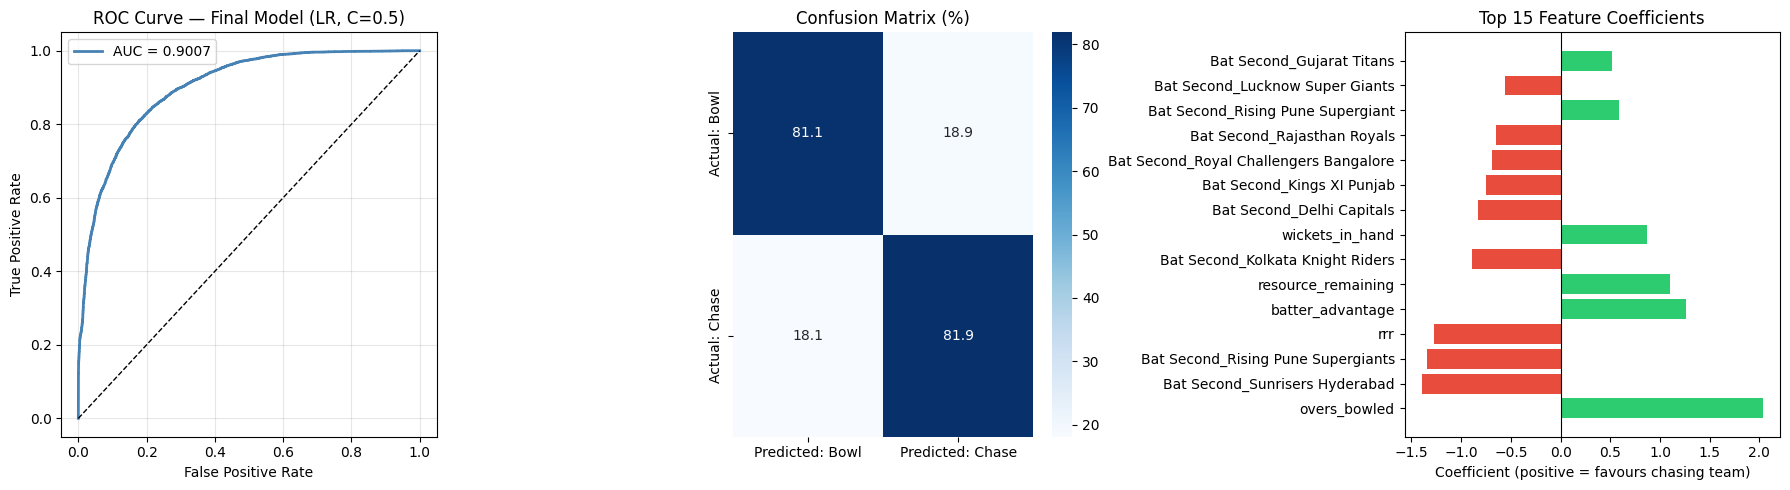

In [17]:
from sklearn.metrics import roc_curve, auc as skl_auc, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curve ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Final Model (LR, C=0.5)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted: Bowl','Predicted: Chase'],
            yticklabels=['Actual: Bowl','Actual: Chase'])
axes[1].set_title('Confusion Matrix (%)')

# ── Feature Importance ───────────────────────────────────────────────────────
coeff_df = pd.DataFrame({'Feature': X_train_sc.columns,
                         'Coefficient': model.coef_[0]})
coeff_df['AbsCoef'] = coeff_df['Coefficient'].abs()
top15 = coeff_df.nlargest(15, 'AbsCoef')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top15['Coefficient']]
axes[2].barh(top15['Feature'], top15['Coefficient'], color=colors)
axes[2].axvline(0, color='black', lw=0.8)
axes[2].set_title('Top 15 Feature Coefficients')
axes[2].set_xlabel('Coefficient (positive = favours chasing team)')

plt.tight_layout(); plt.show()

## 15. Save Artifacts

In [18]:
import joblib, shutil, os

os.makedirs('artifacts', exist_ok=True)
os.makedirs('app/artifacts', exist_ok=True)

# Full teams list including the reference category dropped by drop_first=True
all_teams = sorted(df3['Bat Second'].unique().tolist())

model_data = {
    'model':        model,
    'model_type':   'logistic_regression',
    'scaler':       scaler,
    'features':     all_features,
    'numeric_cols': numeric_cols,
    'all_teams':    all_teams,
    'median_career_sr':     median_career_sr,
    'median_sr_powerplay':  median_sr_powerplay,
    'median_sr_middle':     median_sr_middle,
    'median_sr_death':      median_sr_death,
    'median_eco':           median_eco,
    'median_wicket_rate':   median_wicket_rate,
    'median_eco_powerplay': median_eco_powerplay,
    'median_eco_middle':    median_eco_middle,
    'median_eco_death':     median_eco_death,
    'global_chase_win_pct': global_chase_win_pct,
}
joblib.dump(model_data, 'artifacts/cricket_model.joblib')

# Save lookup CSVs
batter_stats.to_csv('artifacts/batter_stats.csv', index=False)
bowler_stats.to_csv('artifacts/bowler_stats.csv', index=False)
venue_stats.to_csv('artifacts/venue_stats.csv', index=False)

# Copy to app folder
for fname in ['cricket_model.joblib','batter_stats.csv','bowler_stats.csv','venue_stats.csv']:
    shutil.copy(f'artifacts/{fname}', f'app/artifacts/{fname}')

print(f"Model saved.")
print(f"  Features : {len(all_features)}")
print(f"  Teams    : {len(all_teams)} — {all_teams}")
print(f"  Batters  : {len(batter_stats[batter_stats['career_balls'] >= 50])}")
print(f"  Bowlers  : {len(bowler_stats[bowler_stats['b_balls'] >= 60])}")
print(f"  Venues   : {len(venue_stats)}")

Model saved.
  Features : 41
  Teams    : 15 — ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']
  Batters  : 360
  Bowlers  : 357
  Venues   : 41
